## **Modelos com Implementação Própria, NumPy**

**Tarefa 2 do Trabalho Prático — Aprendizagem Profunda**

1. **Stratified K-Fold (K=3)** — Comparação robusta de modelos
2. **Baseline — Regressão Logística Multi-Classe** (Softmax Regression)
3. **DNN — Deep Neural Network** com várias arquiteturas e regularização
4. **Retreino e avaliação** de todos os modelos no dataset de teste

### **1. Imports e Carregamento dos Dados**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time

sys.path.append(os.path.abspath('../src'))

from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from optimizer import Adam, SGD
from logisticregression import LogisticRegression
from utils import (prepare_text_data, prepare_fold_data, transform_new_texts,
                    stratified_k_fold)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

### **2. Carregamento dos Dados**

In [2]:
print("A carregar os datasets...")

# Dataset principal (para K-Fold CV)
df_main = pd.read_csv('../database/dataset.csv', sep=';')
df_main.columns = df_main.columns.str.lower()
textos = df_main['text'].tolist()
labels = df_main['label'].tolist()

# Dataset de teste
df_test = pd.read_csv('../database/dataset-test.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

print(f"  Dataset principal: {len(textos)} textos")
print(f"  Dataset teste: {len(textos_test)} textos")
print(f"  Classes: {sorted(set(labels))}")
print(f"  Distribuição teste: {dict(zip(*np.unique(labels_test, return_counts=True)))}")

A carregar os datasets...
  Dataset principal: 122835 textos
  Dataset teste: 475 textos
  Classes: ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
  Distribuição teste: {np.str_('Anthropic'): np.int64(84), np.str_('Google'): np.int64(76), np.str_('Human'): np.int64(163), np.str_('Meta'): np.int64(78), np.str_('OpenAI'): np.int64(74)}


### **3. Validação Cruzada — Stratified K-Fold (K=3)**

Cada modelo é avaliado com 3-Fold CV estratificado. Em cada fold:
- TF-IDF é ajustado **apenas** nos dados de treino do fold (sem data leakage)
- O modelo treina e é avaliado no fold de validação
- Reportamos **média ± desvio padrão** da accuracy nos 3 folds

In [3]:
K = 3  # K=3 para 122k textos (K=5 demoraria horas em NumPy puro)
FEAT_PARAMS = dict(max_features=3000, char_features=2000, ngram_range=(1, 2), stop_words=set())
# Com 122k textos: 3000 word + 2000 char + 13 style = 5013 features (~5 GB RAM)

def kfold_baseline(textos, labels, k=K, lr_rate=0.05, l2=0.001, epochs=100):
    """K-Fold CV para a Regressão Logística baseline."""
    accs = []
    for fold, (train_idx, val_idx) in enumerate(stratified_k_fold(labels, n_splits=k)):
        texts_tr = [textos[i] for i in train_idx]
        texts_vl = [textos[i] for i in val_idx]
        labels_tr = [labels[i] for i in train_idx]
        labels_vl = [labels[i] for i in val_idx]

        X_tr, Y_tr, X_vl, Y_vl, _, enc = prepare_fold_data(
            texts_tr, labels_tr, texts_vl, labels_vl, **FEAT_PARAMS)

        np.random.seed(42)
        model = LogisticRegression(X_tr.shape[1], Y_tr.shape[1], lr_rate, l2)
        model.fit(X_tr, Y_tr, epochs=epochs, batch_size=64, verbose=False, patience=None)
        _, acc = model.evaluate(X_vl, Y_vl)
        accs.append(acc)
        print(f"  Fold {fold+1}: {acc:.2%}")
    return np.array(accs)

def kfold_dnn(textos, labels, camadas_config, k=K, epochs=100, batch_size=256,
              patience=15, lr=0.0001):
    """K-Fold CV para uma DNN."""
    accs = []
    for fold, (train_idx, val_idx) in enumerate(stratified_k_fold(labels, n_splits=k)):
        texts_tr = [textos[i] for i in train_idx]
        texts_vl = [textos[i] for i in val_idx]
        labels_tr = [labels[i] for i in train_idx]
        labels_vl = [labels[i] for i in val_idx]

        X_tr, Y_tr, X_vl, Y_vl, _, enc = prepare_fold_data(
            texts_tr, labels_tr, texts_vl, labels_vl, **FEAT_PARAMS)

        np.random.seed(42)
        adam = Adam(learning_rate=lr)
        nn = NeuralNetwork(loss_func=CategoricalCrossEntropy())
        prev = X_tr.shape[1]
        for n_units, dropout, l2 in camadas_config:
            nn.add(DenseLayer(prev, n_units, optimizer=adam, l2_lambda=l2))
            nn.add(ReLUActivation())
            if dropout > 0: nn.add(DropoutLayer(rate=dropout))
            prev = n_units
        nn.add(DenseLayer(prev, Y_tr.shape[1], optimizer=adam))
        nn.add(SoftmaxActivation())

        nn.fit(X_tr, Y_tr, epochs=epochs, batch_size=batch_size,
               verbose=False, X_val=X_vl, Y_val=Y_vl, patience=patience)
        _, acc = nn.evaluate(X_vl, Y_vl)
        accs.append(acc)
        print(f"  Fold {fold+1}: {acc:.2%}")
    return np.array(accs)

print("Funções de K-Fold definidas.")

Funções de K-Fold definidas.


### **3.1 Resultados do K-Fold**

In [4]:
cv_results = {}

# Baseline LR
print("\nBaseline LR:")
accs = kfold_baseline(textos, labels)
cv_results["Baseline LR"] = accs
print(f"  → Média: {accs.mean():.2%} ± {accs.std():.2%}")

# DNN configs
dnn_configs = {
    "DNN Wide (256→128)":    [(256, 0.3, 0.0), (128, 0.3, 0.0)],
    "DNN Narrow (128→64)":   [(128, 0.3, 0.0), (64, 0.3, 0.0)],
    "DNN Flat (128→128)":    [(128, 0.3, 0.0), (128, 0.3, 0.0)],
    "DNN Dropout (256→128)": [(256, 0.5, 0.0), (128, 0.5, 0.0)],
    "DNN D+L2 (256→128)":   [(256, 0.5, 0.01), (128, 0.5, 0.01)],
}

for nome, config in dnn_configs.items():
    print(f"\n{nome}:")
    accs = kfold_dnn(textos, labels, config)
    cv_results[nome] = accs
    print(f"  → Média: {accs.mean():.2%} ± {accs.std():.2%}")


Baseline LR:
  Fold 1: 90.58%
  Fold 2: 90.42%
  Fold 3: 90.70%
  → Média: 90.57% ± 0.12%

DNN Wide (256→128):
  Fold 1: 94.65%
  Fold 2: 94.46%
  Fold 3: 94.55%
  → Média: 94.55% ± 0.08%

DNN Narrow (128→64):
  Fold 1: 94.49%
  Fold 2: 94.46%
  Fold 3: 94.51%
  → Média: 94.49% ± 0.02%

DNN Flat (128→128):
  Fold 1: 94.68%
  Fold 2: 94.47%
  Fold 3: 94.48%
  → Média: 94.54% ± 0.10%

DNN Dropout (256→128):
  Fold 1: 94.69%
  Fold 2: 94.54%
  Fold 3: 94.54%
  → Média: 94.59% ± 0.07%

DNN D+L2 (256→128):
  Fold 1: 93.90%
  Fold 2: 93.86%
  Fold 3: 93.89%
  → Média: 93.88% ± 0.02%


In [5]:
# Tabela resumo do K-Fold
rows = []
for nome, accs in cv_results.items():
    rows.append({"Modelo": nome, "Média": f"{accs.mean():.2%}",
                 "Std": f"±{accs.std():.2%}",
                 "Min": f"{accs.min():.2%}", "Max": f"{accs.max():.2%}"})

df_cv = pd.DataFrame(rows).sort_values('Média', ascending=False)
print("Resumo do K-Fold Cross-Validation:")
print(df_cv.to_string(index=False))

Resumo do K-Fold Cross-Validation:
               Modelo  Média    Std    Min    Max
DNN Dropout (256→128) 94.59% ±0.07% 94.54% 94.69%
   DNN Wide (256→128) 94.55% ±0.08% 94.46% 94.65%
   DNN Flat (128→128) 94.54% ±0.10% 94.47% 94.68%
  DNN Narrow (128→64) 94.49% ±0.02% 94.46% 94.51%
   DNN D+L2 (256→128) 93.88% ±0.02% 93.86% 93.90%
          Baseline LR 90.57% ±0.12% 90.42% 90.70%


### **4. Retreino e Avaliação de TODOS os Modelos no Dataset de Teste**

Cada modelo é retreinado com split 80/20 (para early stopping) e depois
avaliado no dataset de teste externo. Isto dá-nos **validação** (K-Fold) e
**teste** (dataset independente) para todos os modelos.

**Melhorias:** ETA em tempo real, curvas de aprendizagem guardadas,
e backup parcial com pickle.

In [6]:
# Preparar dados uma só vez (80/20 para early stopping + teste externo)
print("A preparar dados para retreino de todos os modelos...")
X_train, Y_train, X_val, Y_val, transformers, encoder = prepare_text_data(
    textos, labels,
    max_features=3000, char_features=2000, val_size=0.20,
    use_stratify=True, ngram_range=(1, 2), stop_words=set()
)

X_test = transform_new_texts(textos_test, transformers)
Y_test = encoder.transform(np.array(labels_test))

input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]
class_names = encoder.classes

print(f"  Treino: {X_train.shape} | Val: {X_val.shape} | Teste: {X_test.shape}")

A preparar dados para retreino de todos os modelos...
  Treino: (98270, 5013) | Val: (24565, 5013) | Teste: (475, 5013)


In [ ]:
# Retreinar e avaliar TODOS os modelos
import pickle as _pkl

os.makedirs('../models/backup', exist_ok=True)

resultados_todos = {}
all_histories = {}

global_start = time.time()
total_models = 1 + len(dnn_configs)  # 1 LR + 5 DNNs
done = 0

# --- Baseline LR ---
done += 1
print(f"\n{'='*60}")
print(f"[{done}/{total_models}] Baseline LR")
print("="*60)
np.random.seed(42)
lr_model = LogisticRegression(input_dim, output_dim, 0.05, 0.001)
t0 = time.time()
lr_model.fit(X_train, Y_train, epochs=100, batch_size=256, verbose=True,
             X_val=X_val, Y_val=Y_val, patience=15)
tempo = time.time() - t0
_, train_acc = lr_model.evaluate(X_train, Y_train)
_, val_acc = lr_model.evaluate(X_val, Y_val)
_, test_acc = lr_model.evaluate(X_test, Y_test)
resultados_todos["Baseline LR"] = {
    'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc,
    'tempo': tempo, 'modelo': lr_model, 'tipo': 'Baseline LR'
}
all_histories["Baseline LR"] = lr_model.history
print(f"  Treino: {train_acc:.2%} | Val: {val_acc:.2%} | Teste: {test_acc:.2%} | {tempo:.1f}s")

# --- DNNs ---
for nome, config in dnn_configs.items():
    done += 1
    elapsed = time.time() - global_start
    eta = (elapsed / done) * (total_models - done) if done > 0 else 0
    print(f"\n{'='*60}")
    print(f"[{done}/{total_models}] {nome}  [⏱ {elapsed/60:.1f}min | ETA: {eta/60:.1f}min]")
    print("="*60)
    np.random.seed(42)
    adam = Adam(learning_rate=0.0001)
    nn_model = NeuralNetwork(loss_func=CategoricalCrossEntropy())
    prev = input_dim
    for n_units, dropout, l2 in config:
        nn_model.add(DenseLayer(prev, n_units, optimizer=adam, l2_lambda=l2))
        nn_model.add(ReLUActivation())
        if dropout > 0: nn_model.add(DropoutLayer(rate=dropout))
        prev = n_units
    nn_model.add(DenseLayer(prev, output_dim, optimizer=adam))
    nn_model.add(SoftmaxActivation())

    t0 = time.time()
    nn_model.fit(X_train, Y_train, epochs=150, batch_size=256, verbose=True,
                 X_val=X_val, Y_val=Y_val, patience=15)
    tempo = time.time() - t0
    _, train_acc = nn_model.evaluate(X_train, Y_train)
    _, val_acc = nn_model.evaluate(X_val, Y_val)
    _, test_acc = nn_model.evaluate(X_test, Y_test)
    resultados_todos[nome] = {
        'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc,
        'tempo': tempo, 'modelo': nn_model, 'tipo': nome
    }
    all_histories[nome] = nn_model.history
    print(f"  Treino: {train_acc:.2%} | Val: {val_acc:.2%} | Teste: {test_acc:.2%} | {tempo:.1f}s")

    # Backup parcial
    _pkl.dump({k: {kk: vv for kk, vv in v.items() if kk != 'modelo'}
               for k, v in resultados_todos.items()},
              open('../models/backup/_numpy_partial.pkl', 'wb'))

total_time = (time.time() - global_start) / 60
print(f"\n✅ Todos os modelos treinados e avaliados em {total_time:.1f} min.")


[1/6] Baseline LR
Epoch    1/100 | Loss: 1.0423 | Val Loss: 1.0379 | Acc: 58.35% | Val Acc: 58.39%
Epoch   11/100 | Loss: 0.8594 | Val Loss: 0.8569 | Acc: 69.62% | Val Acc: 69.90%
Epoch   21/100 | Loss: 0.7548 | Val Loss: 0.7541 | Acc: 75.45% | Val Acc: 75.55%
Epoch   31/100 | Loss: 0.6807 | Val Loss: 0.6813 | Acc: 78.97% | Val Acc: 78.77%
Epoch   41/100 | Loss: 0.6253 | Val Loss: 0.6270 | Acc: 81.31% | Val Acc: 81.07%
Epoch   51/100 | Loss: 0.5823 | Val Loss: 0.5846 | Acc: 82.94% | Val Acc: 82.70%
Epoch   61/100 | Loss: 0.5478 | Val Loss: 0.5509 | Acc: 84.21% | Val Acc: 84.02%
Epoch   71/100 | Loss: 0.5194 | Val Loss: 0.5231 | Acc: 85.14% | Val Acc: 84.89%
Epoch   81/100 | Loss: 0.4957 | Val Loss: 0.4998 | Acc: 85.91% | Val Acc: 85.60%
Epoch   91/100 | Loss: 0.4755 | Val Loss: 0.4801 | Acc: 86.54% | Val Acc: 86.20%
Epoch  100/100 | Loss: 0.4596 | Val Loss: 0.4646 | Acc: 87.03% | Val Acc: 86.65%
Melhores pesos restaurados.
  Treino: 87.03% | Val: 86.65% | Teste: 69.47% | 339.3s

[2/6]

### **4.1 Tabela Comparativa — Validação (K-Fold) vs Teste**

In [9]:
# Tabela comparativa: K-Fold CV vs Teste
rows = []
for nome in cv_results:
    kfold_mean = cv_results[nome].mean()
    kfold_std = cv_results[nome].std()
    r = resultados_todos[nome]
    rows.append({
        "Modelo": nome,
        "K-Fold (média±std)": f"{kfold_mean:.2%} ±{kfold_std:.2%}",
        "Treino": f"{r['train_acc']:.2%}",
        "Validação (20%)": f"{r['val_acc']:.2%}",
        "Teste": f"{r['test_acc']:.2%}",
        "Tempo (s)": f"{r['tempo']:.1f}"
    })

df_comp = pd.DataFrame(rows).sort_values('Teste', ascending=False)
print("Comparação Validação vs Teste — Todos os Modelos:\n")
print(df_comp.to_string(index=False))

# Identificar melhor modelo pelo teste
melhor_nome = df_comp.iloc[0]['Modelo']
print(f"\n🏆 Melhor modelo no teste: {melhor_nome} — {resultados_todos[melhor_nome]['test_acc']:.2%}")

Comparação Validação vs Teste — Todos os Modelos:

               Modelo K-Fold (média±std) Treino Validação (20%)  Teste Tempo (s)
  DNN Narrow (128→64)      94.49% ±0.02% 97.83%          94.68% 75.37%     626.5
DNN Dropout (256→128)      94.59% ±0.07% 97.87%          94.86% 74.74%     896.6
   DNN Wide (256→128)      94.55% ±0.08% 98.26%          95.00% 74.11%     902.5
   DNN Flat (128→128)      94.54% ±0.10% 98.09%          94.83% 73.47%     589.2
   DNN D+L2 (256→128)      93.88% ±0.02% 96.26%          94.22% 73.26%    4535.1
          Baseline LR      90.57% ±0.12% 87.03%          86.65% 69.47%     339.3

🏆 Melhor modelo no teste: DNN Narrow (128→64) — 75.37%


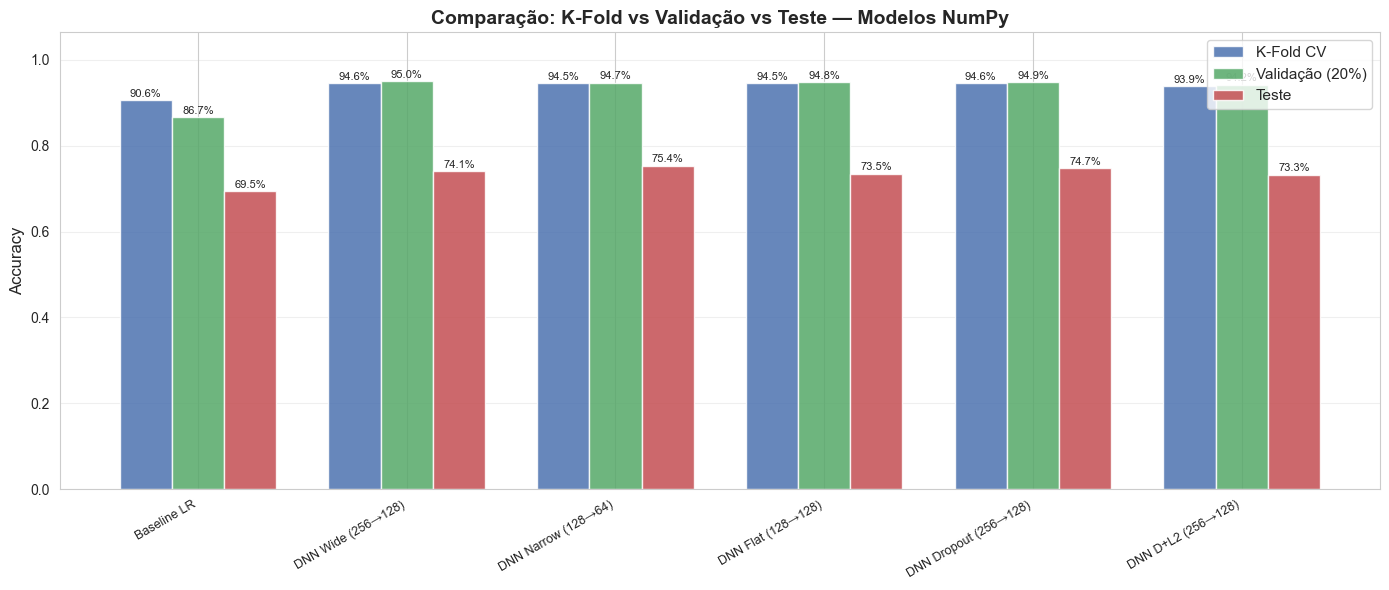

In [10]:
# Gráfico de barras: Validação (K-Fold) vs Teste
nomes = list(resultados_todos.keys())
kfold_accs = [cv_results[n].mean() for n in nomes]
val_accs = [resultados_todos[n]['val_acc'] for n in nomes]
test_accs = [resultados_todos[n]['test_acc'] for n in nomes]

x = np.arange(len(nomes))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, kfold_accs, width, label='K-Fold CV', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x, val_accs, width, label='Validação (20%)', color='#55A868', alpha=0.85)
bars3 = ax.bar(x + width, test_accs, width, label='Teste', color='#C44E52', alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.1%}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparação: K-Fold vs Validação vs Teste — Modelos NumPy',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nomes, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(kfold_accs), max(val_accs), max(test_accs)) * 1.12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### **4.2 Curvas de Aprendizagem — Todos os Modelos**

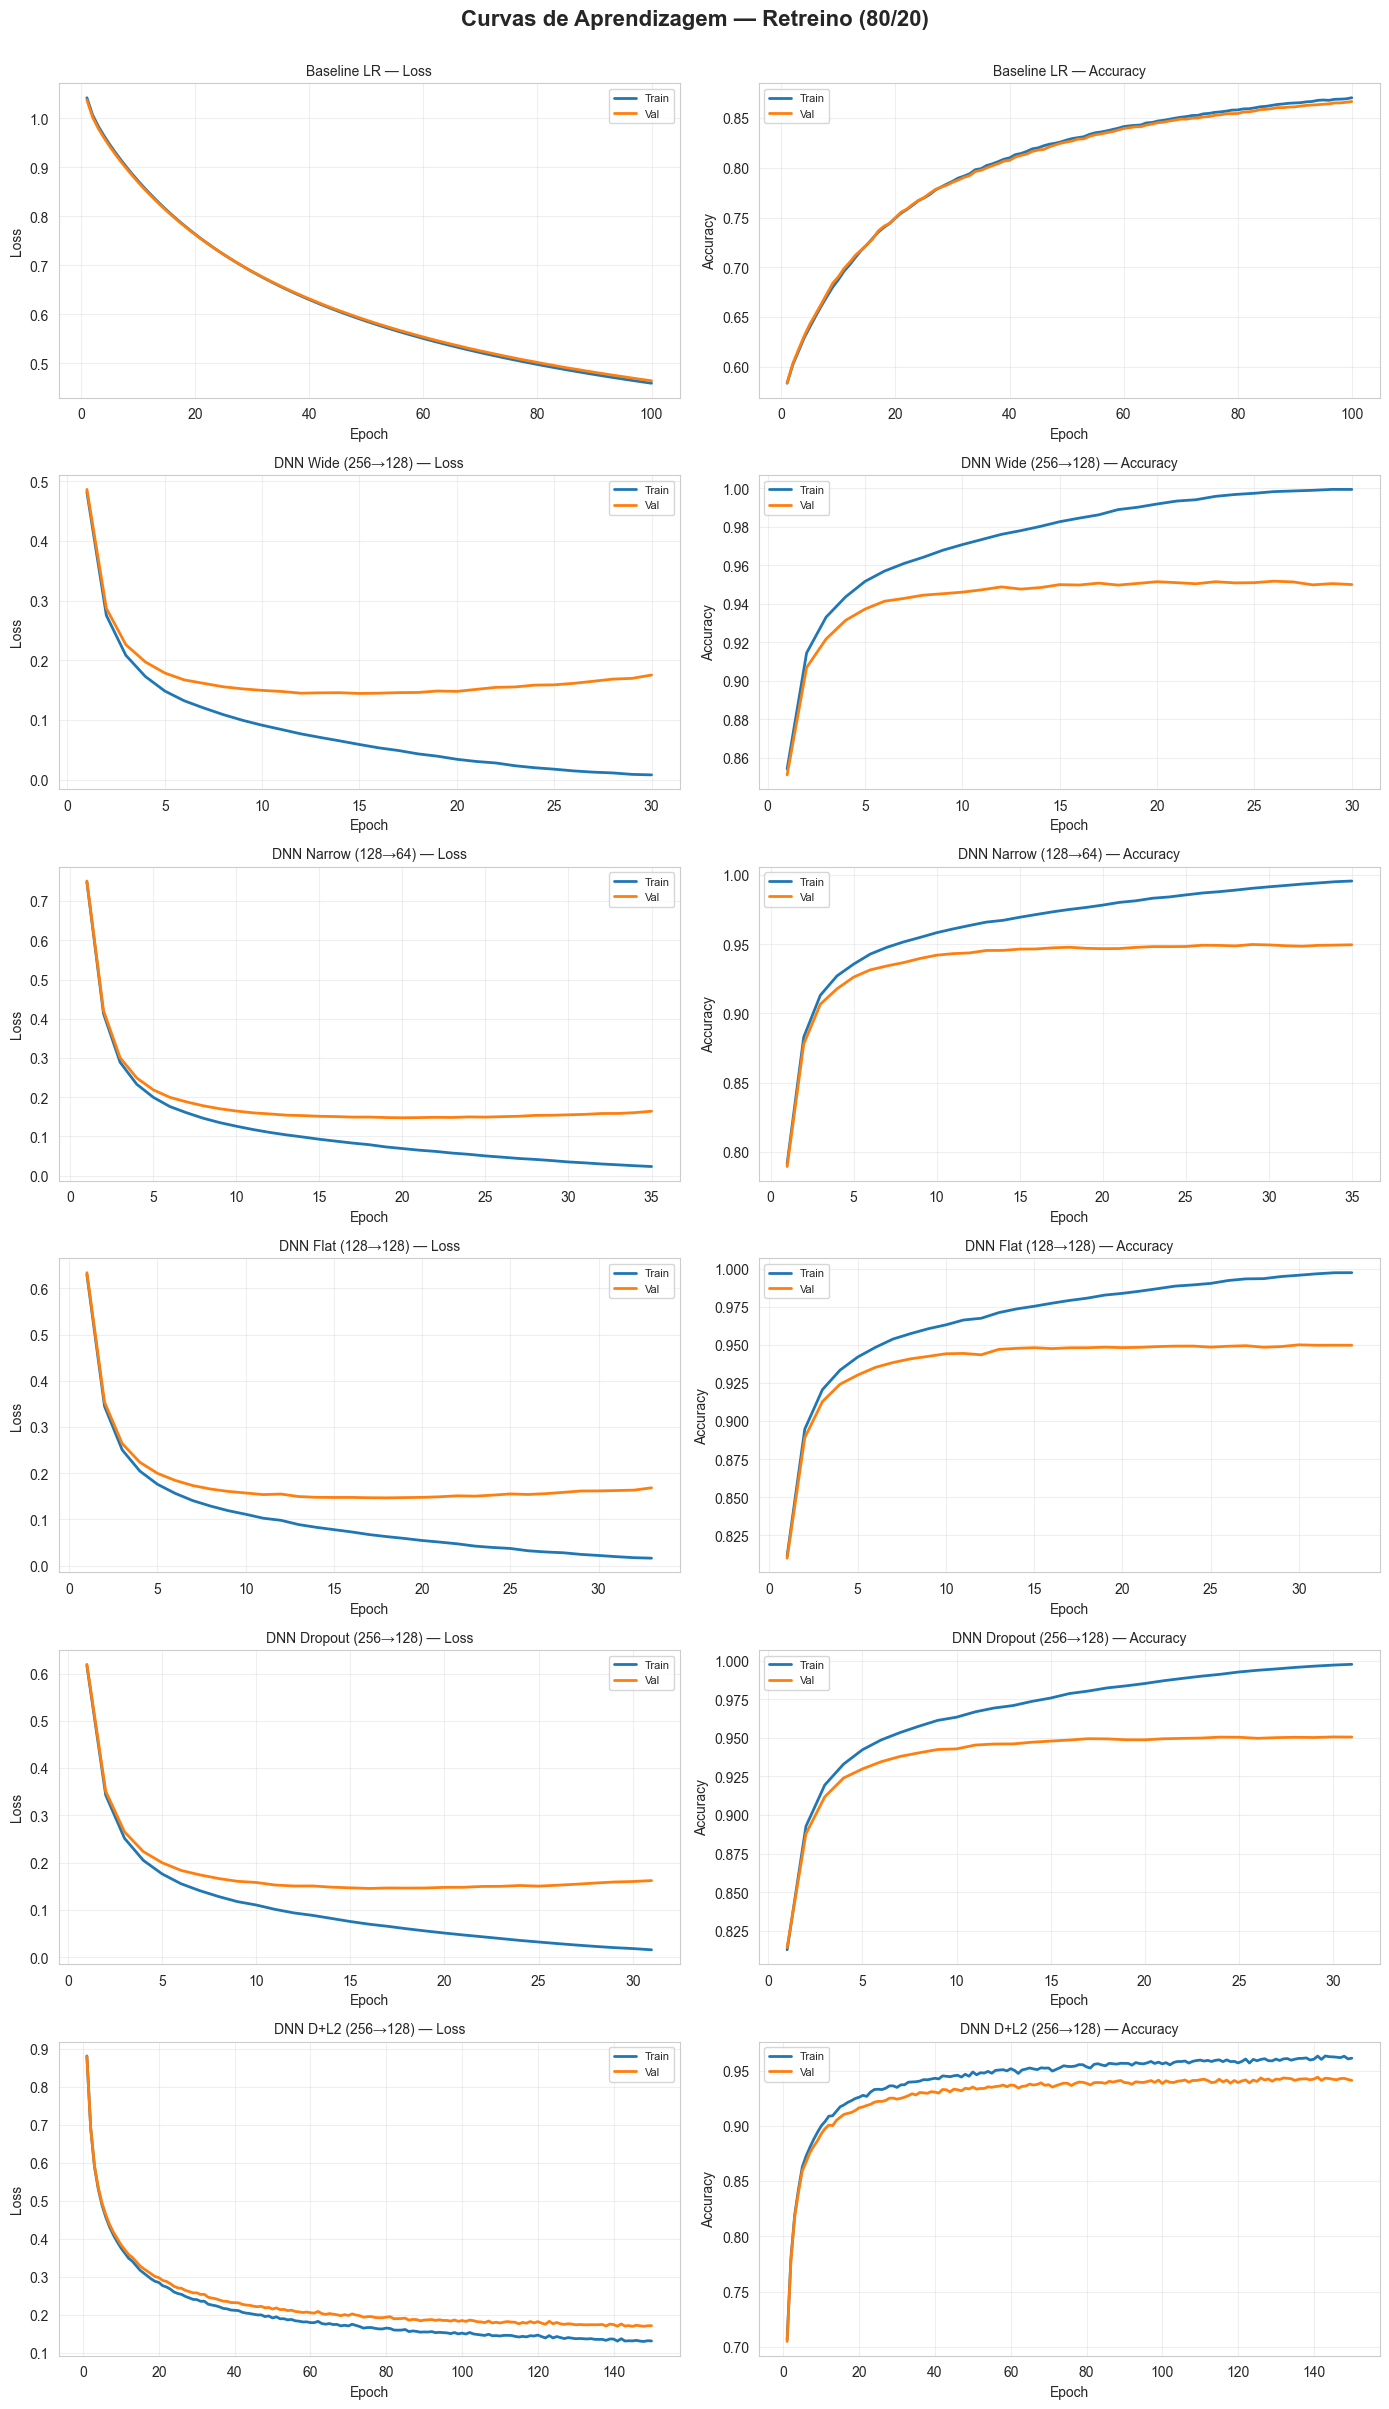

In [11]:
# Curvas de aprendizagem de todos os modelos
n_modelos = len(all_histories)
fig, axes = plt.subplots(n_modelos, 2, figsize=(14, 4 * n_modelos))
if n_modelos == 1:
    axes = axes.reshape(1, -1)

for idx, (nome, hist) in enumerate(all_histories.items()):
    # Loss
    ax = axes[idx, 0]
    epochs_range = range(1, len(hist['loss']) + 1)
    ax.plot(epochs_range, hist['loss'], label='Train', linewidth=2)
    if hist.get('val_loss'):
        ax.plot(epochs_range, hist['val_loss'], label='Val', linewidth=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(f'{nome} — Loss', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Accuracy
    ax = axes[idx, 1]
    if hist.get('acc'):
        ax.plot(epochs_range, hist['acc'], label='Train', linewidth=2)
    if hist.get('val_acc'):
        ax.plot(epochs_range, hist['val_acc'], label='Val', linewidth=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.set_title(f'{nome} — Accuracy', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizagem — Retreino (80/20)', fontsize=16, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()

### **5. Avaliação Final — Confusion Matrix e Classification Report (Todos os Modelos)**

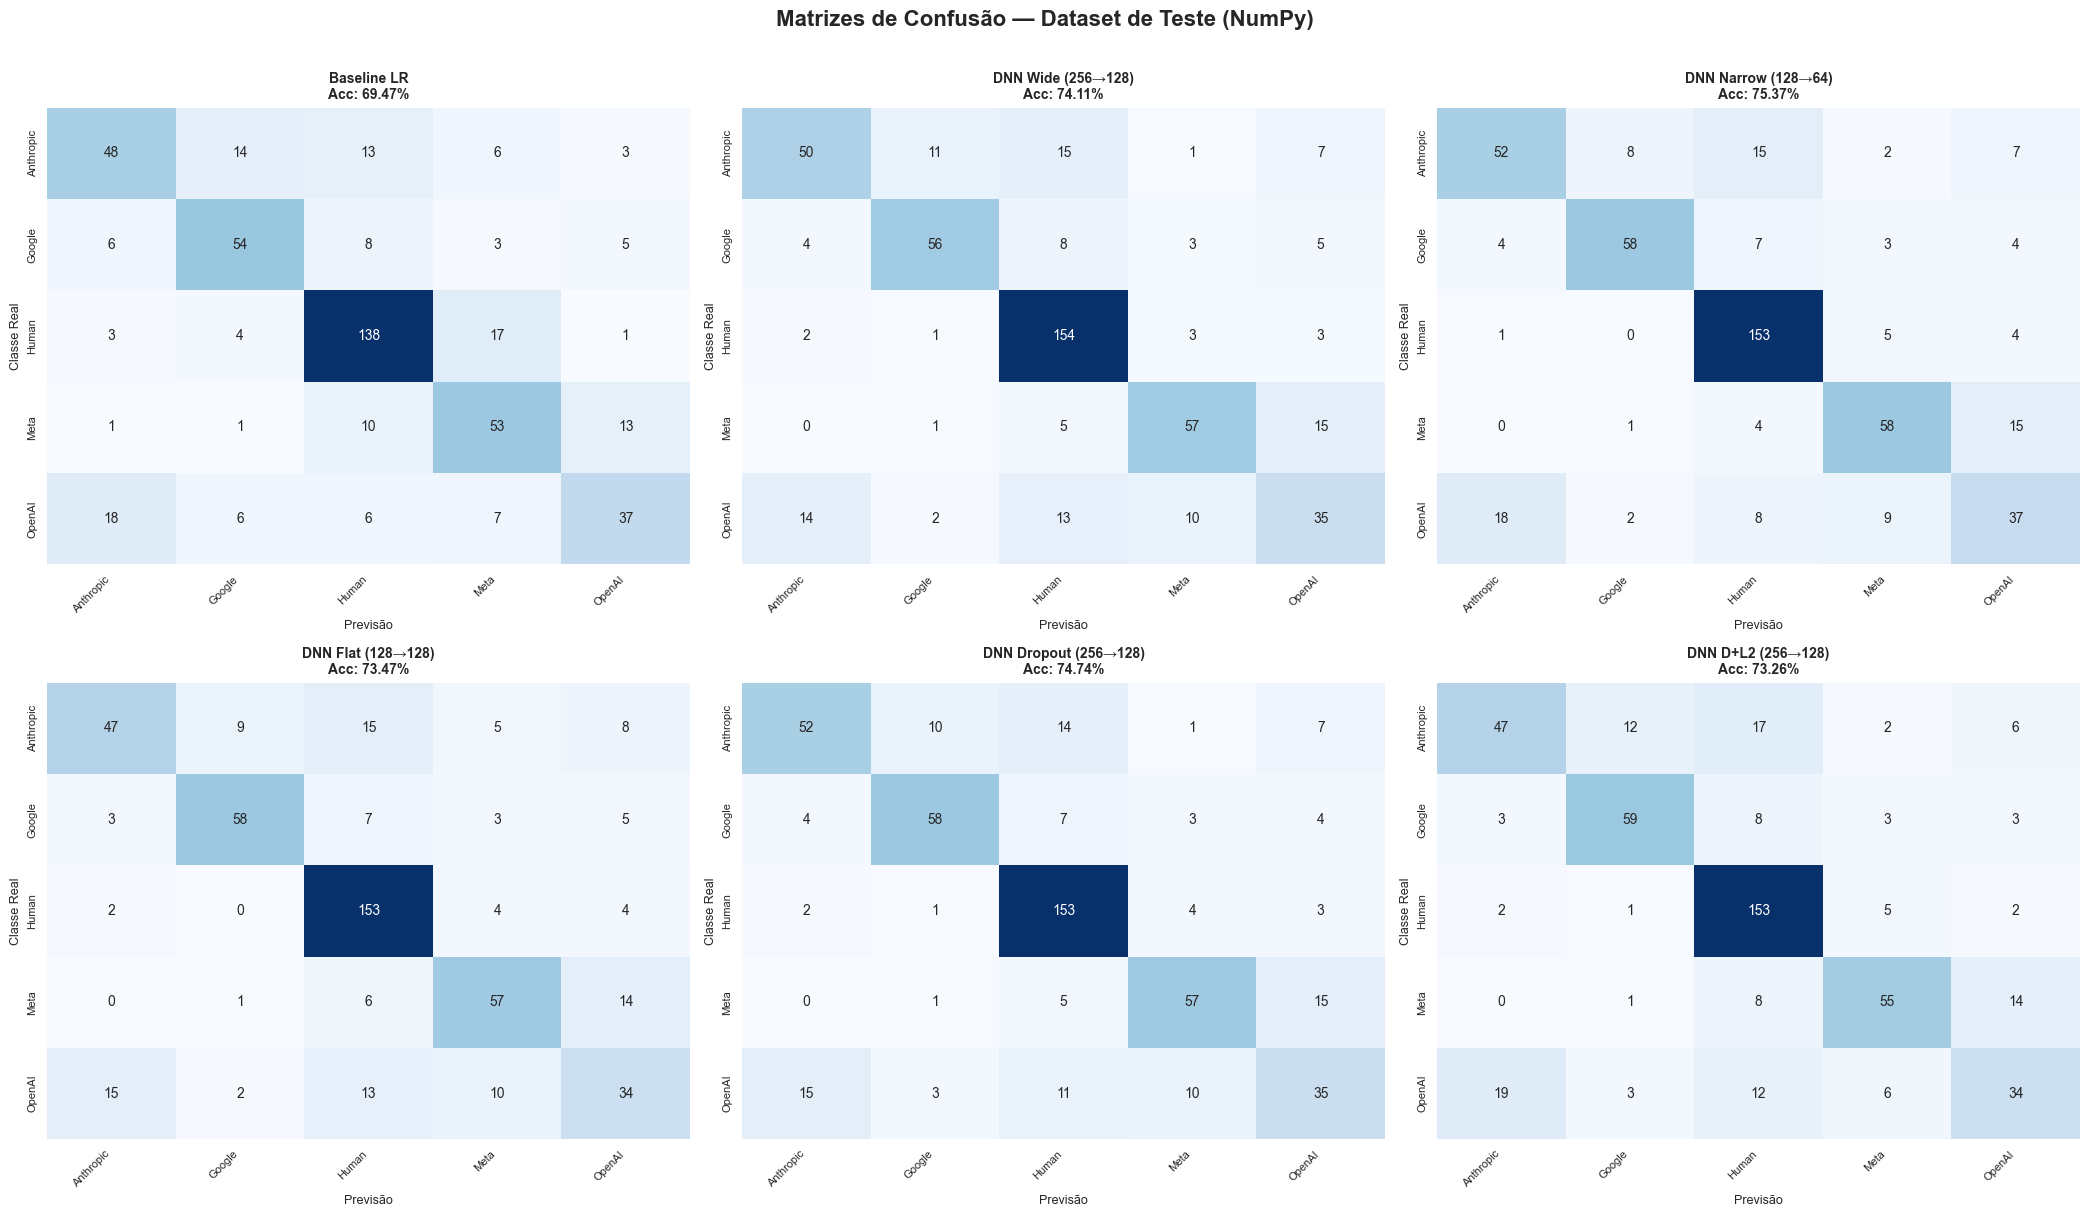

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

y_true_test = np.argmax(Y_test, axis=1)

n_modelos = len(resultados_todos)
n_cols = min(3, n_modelos)
n_rows = (n_modelos + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
axes = np.array(axes).flatten() if n_modelos > 1 else [axes]

for idx, (nome, r) in enumerate(resultados_todos.items()):
    modelo = r['modelo']
    if r['tipo'] == 'Baseline LR':
        y_pred = modelo.predict(X_test)
    else:
        modelo.set_training(False)
        y_pred = np.argmax(modelo.predict(X_test), axis=1)

    cm = confusion_matrix(y_true_test, y_pred)
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_xlabel('Previsão', fontsize=9)
    ax.set_ylabel('Classe Real', fontsize=9)
    ax.set_title(f'{nome}\nAcc: {r["test_acc"]:.2%}', fontweight='bold', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrizes de Confusão — Dataset de Teste (NumPy)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Classification Reports para todos os modelos
for nome, r in resultados_todos.items():
    modelo = r['modelo']
    if r['tipo'] == 'Baseline LR':
        y_pred = modelo.predict(X_test)
    else:
        modelo.set_training(False)
        y_pred = np.argmax(modelo.predict(X_test), axis=1)

    print(f"\n{'='*60}")
    print(f"Classification Report — {nome} (Teste: {r['test_acc']:.2%})")
    print("="*60)
    print(classification_report(y_true_test, y_pred, target_names=class_names, zero_division=0))


Classification Report — Baseline LR (Teste: 69.47%)
              precision    recall  f1-score   support

   Anthropic       0.63      0.57      0.60        84
      Google       0.68      0.71      0.70        76
       Human       0.79      0.85      0.82       163
        Meta       0.62      0.68      0.65        78
      OpenAI       0.63      0.50      0.56        74

    accuracy                           0.69       475
   macro avg       0.67      0.66      0.66       475
weighted avg       0.69      0.69      0.69       475


Classification Report — DNN Wide (256→128) (Teste: 74.11%)
              precision    recall  f1-score   support

   Anthropic       0.71      0.60      0.65        84
      Google       0.79      0.74      0.76        76
       Human       0.79      0.94      0.86       163
        Meta       0.77      0.73      0.75        78
      OpenAI       0.54      0.47      0.50        74

    accuracy                           0.74       475
   macro avg      

### **6. Guardar o Melhor Modelo**

In [14]:
import pickle

melhor_modelo_obj = resultados_todos[melhor_nome]['modelo']
melhor_tipo = resultados_todos[melhor_nome]['tipo']

modelo_para_guardar = {
    'modelo_tipo': melhor_tipo,
    'transformers': transformers,
    'encoder': encoder,
    'class_names': class_names,
}

if melhor_tipo == 'Baseline LR':
    modelo_para_guardar['weights'] = melhor_modelo_obj.weights
    modelo_para_guardar['biases'] = melhor_modelo_obj.biases
else:
    pesos = []
    for layer in melhor_modelo_obj.layers:
        if hasattr(layer, 'get_weights'):
            pesos.append(layer.get_weights())
        else:
            pesos.append(None)
    modelo_para_guardar['pesos_camadas'] = pesos

caminho = '../models/numpy.pkl'
os.makedirs('../models', exist_ok=True)
with open(caminho, 'wb') as f:
    pickle.dump(modelo_para_guardar, f)
print(f"✅ Modelo guardado em '{caminho}'")
print(f"   Tipo: {melhor_tipo}")
print(f"   Teste Acc: {resultados_todos[melhor_nome]['test_acc']:.2%}")

✅ Modelo guardado em '../models/numpy.pkl'
   Tipo: DNN Narrow (128→64)
   Teste Acc: 75.37%
